## Imports

In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories

  Activating project at `~/notebooks/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumColloc

In [2]:
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);

## Functions

In [3]:
function var_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / (T * Δt)^2 / d
end

function tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64}
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))
    
    # Toggle integral
    H_ti = sum(Δt[i] .* U[i]' * H_error * U[i] for i=1:T-1)

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

function commutator(A::AbstractMatrix{<:Number}, B::AbstractMatrix{<:Number})
    return A*B - B*A
end

function pert_tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    order::Int=1,
    a_bound::Float64=a_bound
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))

    # toggle integral
    H_ti = zeros(ComplexF64, size(U[1]))

    # note: U_1 = I, so U[:, k] = U_{k-1}.
    # you need to go to T-1, only
    for k in 1:T-1
        Hₖ = sum(traj.a[l, k] / a_bound * H for (l, H) in enumerate(H_drives))
        adjⁿH_E = H_error
        Eₖ_n = H_error * Δt[k]
        
        # get the different orders of the Hadamard lemma
        for n in 2:order
            coef_n = ComplexF64(im^(n-1) * a_bound^(n-1) * Δt[k]^n / factorial(big(n)))
            adjⁿH_E = commutator(Hₖ, adjⁿH_E)
            # Eₖ_n = push!(Eₖ_n, coef_n * adjⁿH_E)
            Eₖ_n += coef_n * adjⁿH_E
        end

        # nth order toggle integral up to k
        H_ti += U[k]' * Eₖ_n * U[k]
    end

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

pert_tog_obj (generic function with 1 method)

In [4]:
"""
    upsample_constant(vals, dts; factor=2)

Take control values `vals` with time steps `dts` (same length),
and upsample by `factor`, returning (vals_up, dts_up).
"""
function upsample_constant_controls(vals::AbstractArray; factor::Int=2)
    vals_up = repeat(vals, inner=factor)
    return vals_up
end

function upsample_matrix(controls::AbstractArray, dts::AbstractArray; factor::Int=2)
    new_controls = []
    for c in eachrow(controls)
        new_c = upsample_constant_controls(c; factor=factor)
        push!(new_controls, new_c)
    end
    T = length(controls[1,:])
    dts_up = dts[1] / factor .* ones(length(dts) * factor * T)
    new_controls = reduce(vcat, [v' for v in new_controls])
    return new_controls, dts_up
end

function tog_obj_upsample(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    factor::Int=1
)
    T = traj.T * factor
    controls = traj.a
    a_new, Δt_new = upsample_matrix(traj.a, traj.Δt; factor=factor)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(a_new, Δt_new, sys)))
    
    # Toggle integral (truncate at (traj.T - 1) * factor)
    H_ti = sum(Δt_new[i] .* U[i]' * H_error * U[i] for i = 1:(traj.T - 1) * factor)

    d₁ = size(U[1], 1)
    Δt₁ = Δt_new[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

tog_obj_upsample (generic function with 1 method)

## Loop

In [5]:
U_goal = GATES.H
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
piccolo_opts = PiccoloOptions(verbose=false)
sys = QuantumSystem(H_drive)
seed = 42
F = 0.9999
num_iter = 2
hess = false
hess_iter = 2000

a_bound = 1.0
dda_bound = 10.0

H_errors = [PAULIS.Z]
TΔt = 32

32

In [ ]:
knot_data = []
toggle_peturb_data = []
integral_limit_data = []
variational_data = []

for N in [2^5, 2^6, 2^7, 2^8] #
    push!(knot_data, N)

    # Run problem
    # -----------
    # Shared problem parameters
    T = N
    Δt = TΔt / T

    # Adjoint, rollout initialization
    Random.seed!(seed)
    varsys_add = VariationalQuantumSystem(H_drive, H_errors)

    var_count = length(varsys_add.G_vars)

    var_prob = UnitaryVariationalProblem(
        varsys_add, U_goal, T, Δt;
        robust_times = [[T] for _ in 1:var_count],
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        Q=0.0,
        Q_r = 1.0,   # > 0
        Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
        piccolo_options = PiccoloOptions(verbose=false)
    )

    # Initialize with a rollout, not the geodesic
    init_traj = deepcopy(var_prob.trajectory)
    init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)

    var_prob = UnitaryVariationalProblem(
        varsys_add, U_goal, T, Δt;
        robust_times = [[T] for _ in 1:var_count],
        init_trajectory = remove_components(init_traj, [:Ũ⃗ᵥ1, :Ũ⃗ᵥ2, :Ũ⃗ᵥ3]),
        a_bound=a_bound, 
        dda_bound=dda_bound,
        Δt_max=Δt,
        Δt_min=Δt,
        Q=0.0,
        Q_r = 1.0,   # > 0
        Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
        piccolo_options = PiccoloOptions(verbose=false)
    )
    push!(
        var_prob.constraints, 
        FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory)
    );

    solve!(var_prob, max_iter=num_iter, print_level=1, options=IpoptOptions(eval_hessian=false))
    solve!(var_prob, max_iter=1000, print_level=5, options=IpoptOptions(eval_hessian=true))
    save("var_traj_robust_z_T_$(T)_dt_$(Δt)_seed_$(seed).jld2", var_prob.trajectory)

    # Save results (could reload traj and compute!)
    # ------------
    t_vec_p = []
    j_vals = 1:5
    for j in j_vals
        push!(t_vec_p, pert_tog_obj(var_prob.trajectory, H_drive, GATES.Z, order=j, a_bound=a_bound))
        # push!(t_vec, tog_obj_upsample(var_traj, H_drive, PAULIS.Z; factor=2^j))
    end

    var_val = var_obj(var_prob.trajectory, H_drive, H_errors)

    intg_lim = tog_obj_upsample(var_prob.trajectory, H_drive, PAULIS.Z; factor=2^10)

    println("")
    println("============================================================================")
    println("Δt = $(Δt), N = $(N) ")
    println("  Perturbative toggle values: $(t_vec_p)")
    println("  Variational objective: $(var_val)")
    println("  Integral limit (factor=2^10): $(intg_lim)")
    println("============================================================================")
    println("")

    push!(toggle_peturb_data, t_vec_p)
    push!(integral_limit_data, intg_lim)
    push!(variational_data, var_val)
end

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: initial value of Ũ⃗ᵥ1
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in eq

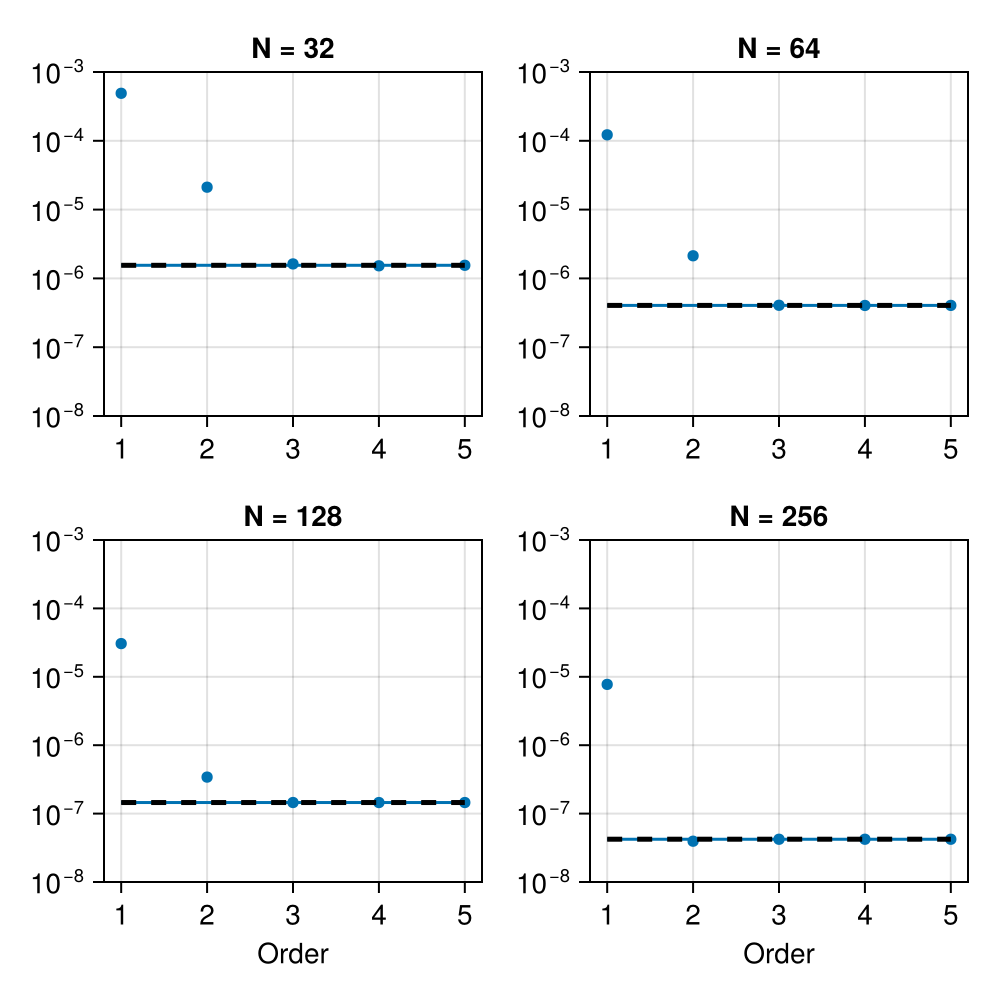

In [6]:
fig = Figure(size=(500, 500))

seed=42
knot_data = [2^5, 2^6, 2^7, 2^8]

for (i, N) in enumerate(knot_data)
    Δt = TΔt / N

    traj = load_traj("var_traj_robust_z_T_$(N)_dt_$(Δt)_seed_$(seed).jld2")

    t_vec_p = []
    j_vals = 1:5
    for j in j_vals
        push!(t_vec_p, pert_tog_obj(traj, H_drive, GATES.Z, order=j, a_bound=a_bound))
    end
    var_val = var_obj(traj, H_drive, H_errors)
    v_vec = var_val .* ones(length(j_vals))
    intg_lim = tog_obj_upsample(traj, H_drive, PAULIS.Z; factor=2^10)

    # intg_lim = integral_limit_data[i]
    # v_vec = variational_data[i] .* ones(length(j_vals))
    # t_vec_p = toggle_peturb_data[i]

    if i < 3
        ax = Axis(
            fig[1, i], title="N = $N", #xlabel="Order", 
            yscale=log10, limits=(nothing, (1e-8, 1e-3))
        )
    else
        ax = Axis(
            fig[2, i-2], title="N = $N", xlabel="Order", 
            yscale=log10, limits=(nothing, (1e-8, 1e-3))
        )
    end
    lines!(ax, j_vals, v_vec; label="Variational")
    scatter!(ax, j_vals, t_vec_p; label="Toggle perturbative", markersize=8)
    # scatter!(ax, j_vals, t_vec; label="Toggle upsample", markersize=8)
    lines!(
        ax, [j_vals[1], j_vals[end]], [intg_lim, intg_lim],
        label="Integral", linestyle=:dash, color=:black, linewidth=2.5
    )
end

save("perturbation_theory.png", fig)
fig

In [8]:
using MathTeXEngine

latex_serif_theme = Theme(
    fontsize = 40,
    fonts = (; 
        regular = texfont(:text), 
        bold = texfont(:bold), 
        italic = texfont(:italic), 
        bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie"
    ),
    Axis = (; 
        xticklabelsize=30,
        yticklabelsize=30,
        xgridvisible=false
    )
)

set_theme!(latex_serif_theme)

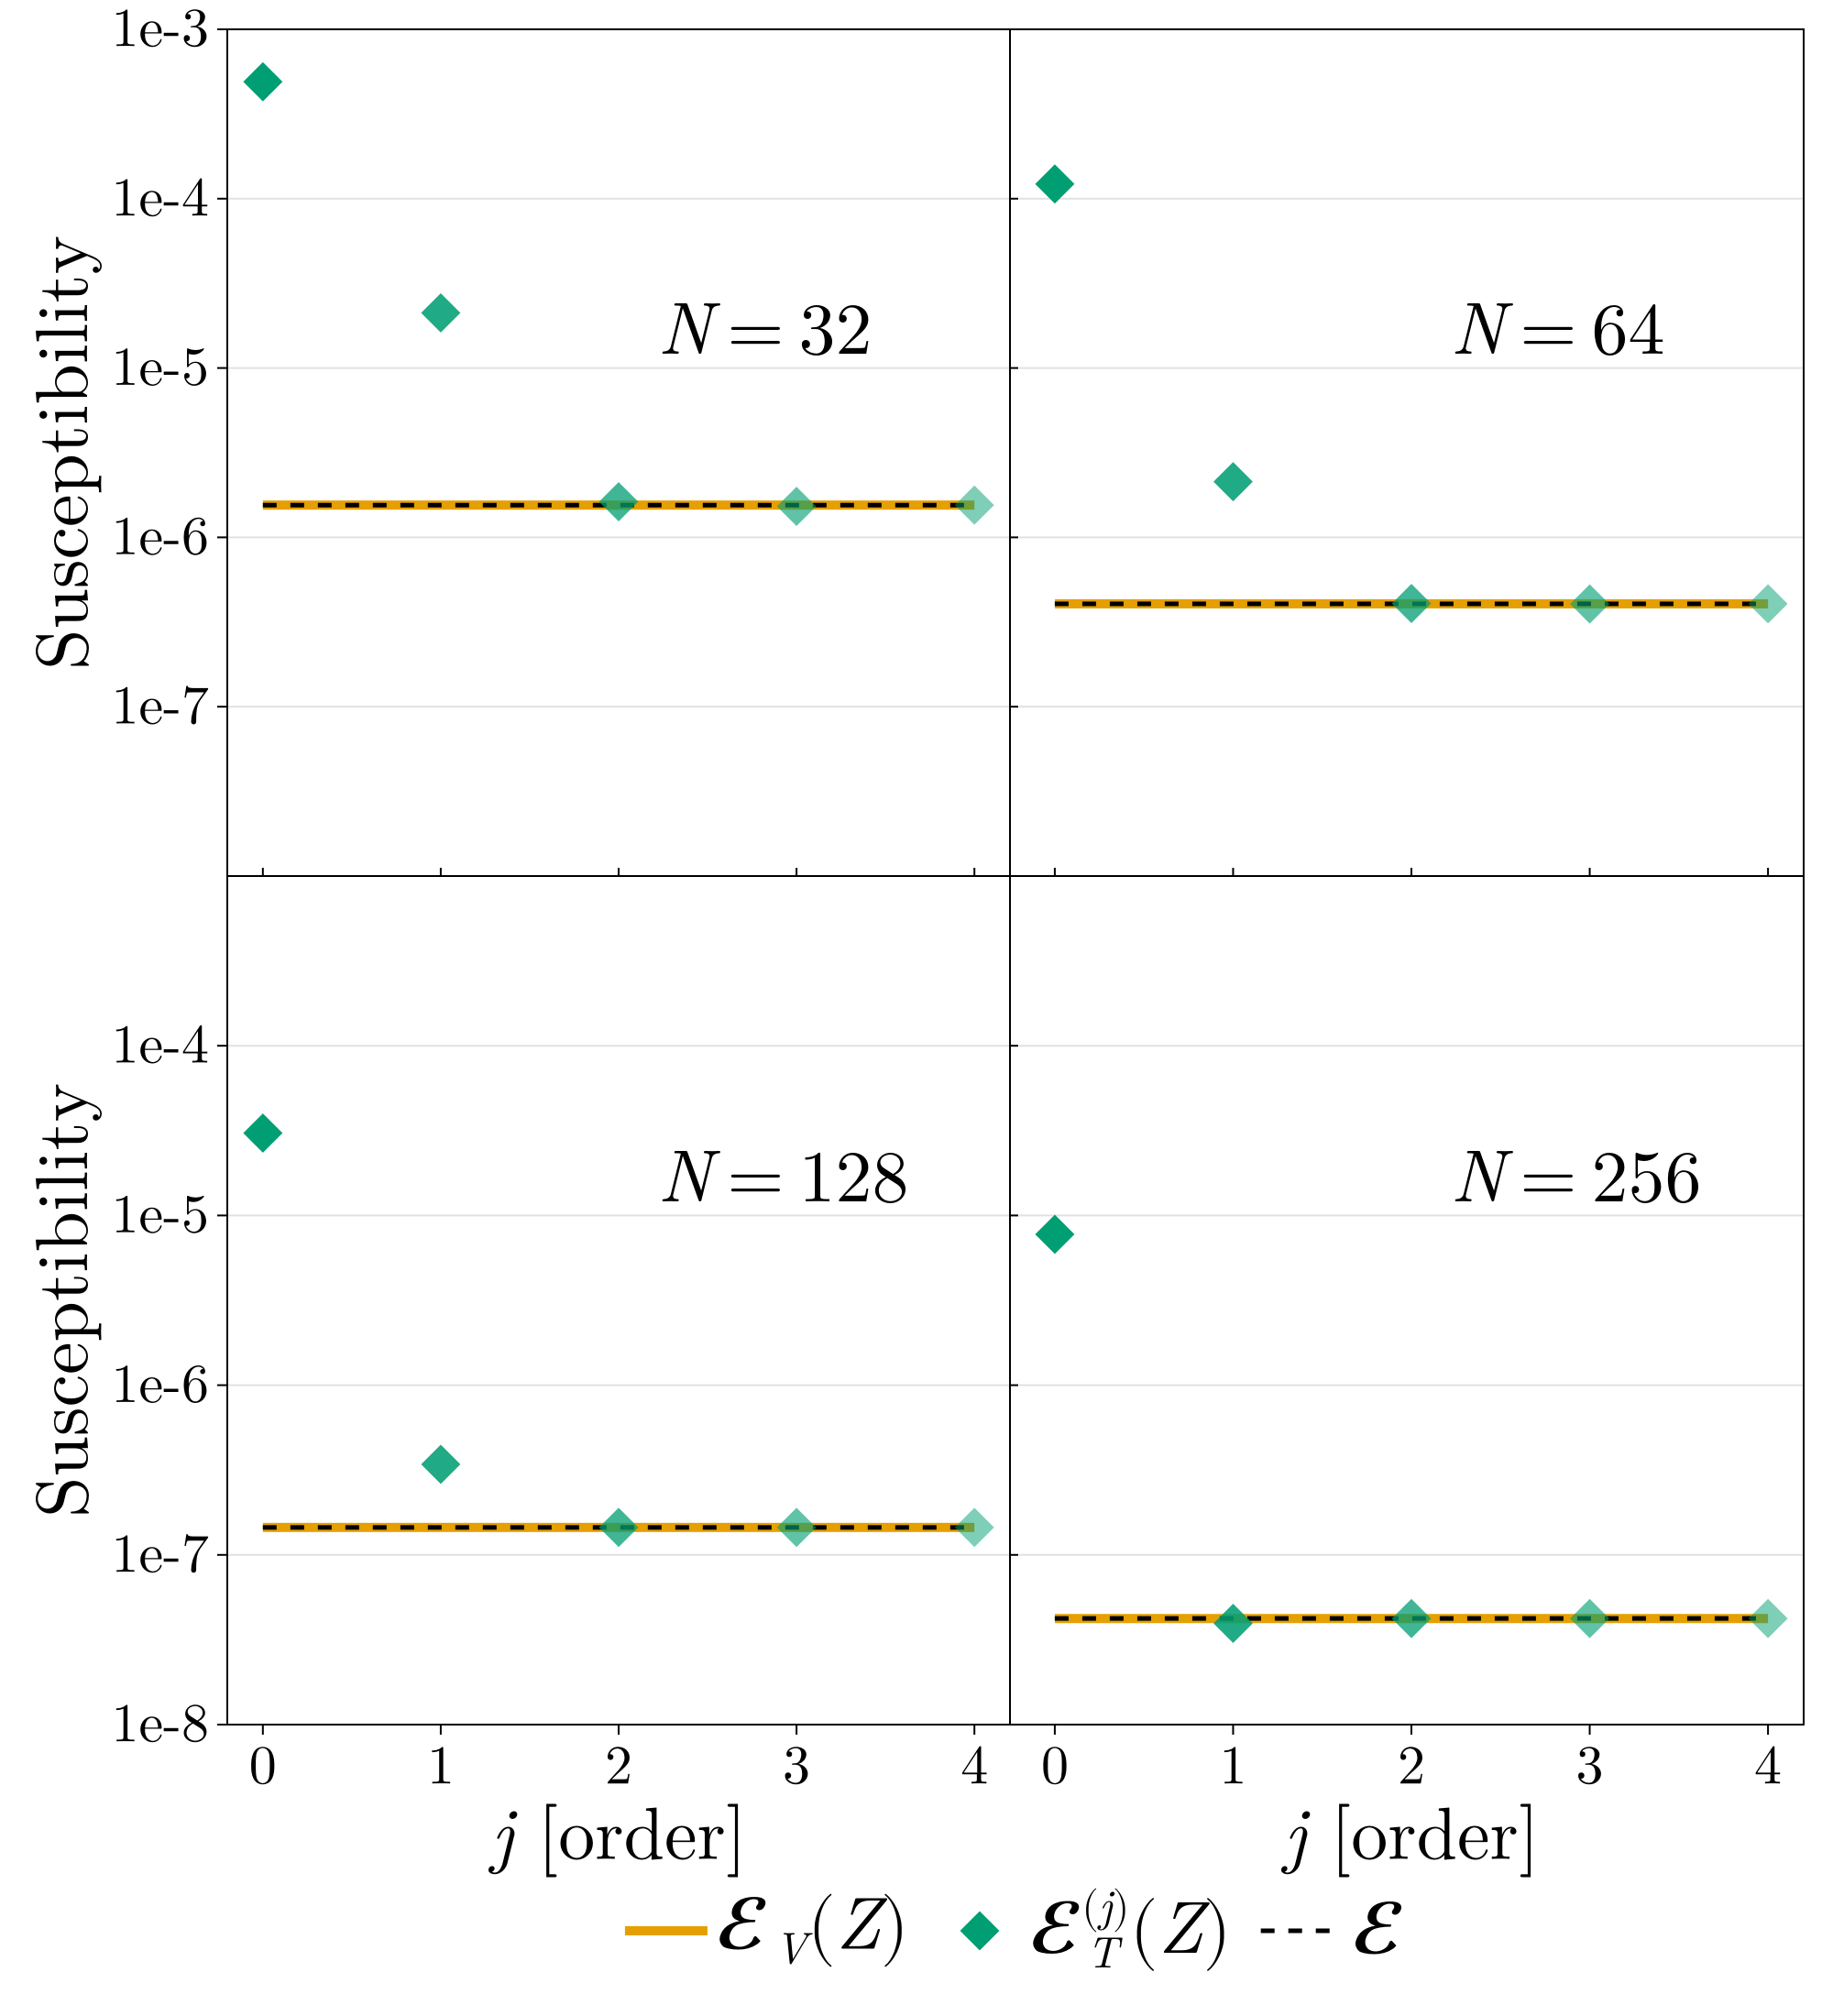

CairoMakie.Screen{IMAGE}


In [11]:
using CairoMakie
using JLD2

# Assuming you have these functions defined elsewhere:
# pert_tog_obj, var_obj, tog_obj_upsample, load_traj
# H_drive, H_errors, GATES.Z, PAULIS.Z, TΔt, a_bound

fig = Figure(size=(1000, 1100))

seed = 42
knot_data = [2^5, 2^6, 2^7, 2^8]

# Store plot elements for legend
line_var = nothing
scatter_tog = nothing
line_intg = nothing

for (i, N) in enumerate(knot_data)
    Δt = TΔt / N

    traj = load_traj("var_traj_robust_z_T_$(N)_dt_$(Δt)_seed_$(seed).jld2")

    t_vec_p = []
    j_vals = 1:5
    for j in j_vals
        push!(t_vec_p, pert_tog_obj(traj, H_drive, GATES.Z, order=j, a_bound=a_bound))
    end
    var_val = var_obj(traj, H_drive, H_errors)
    v_vec = var_val .* ones(length(j_vals))
    intg_lim = tog_obj_upsample(traj, H_drive, PAULIS.Z; factor=2^10)

    # Create axis in 2x2 grid
    if i <= 2
        ax = Axis(
            fig[1, i], 
            #title="N = $N",
            yscale=log10, 
            limits=(nothing, (1e-8, 1e-3)),
            ylabel=(i == 1 ? L"\text{Susceptibility}" : ""),
            titlesize = 18,
            xlabelsize = 40,
            ylabelsize = 40,
            xticklabelsize = 30,
            yticklabelsize = 30
        )
        hidexdecorations!(ax; grid=false, ticks=false, label=false)
        #hidespines!(ax, :b)
        ax.xtickalign[] = 1
        if i == 1
            text!(ax, L"N = 32";
            position = (0.55, 0.6),
            space = :relative,
            fontsize = 40)

            # choose fixed log ticks
            yticks = 10.0 .^ (-7:-3)  # [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
            ylabels = ["1e-7", "1e-6", "1e-5", "1e-4", "1e-3"]
    
            ax.yticks[] = (yticks, ylabels)
        end
        if i == 2
            text!(ax, L"{N = 64}";
            position = (0.55, 0.6),
            space = :relative,
            fontsize = 40)
            hideydecorations!(ax; grid=false, ticks=false, label=false)
            hidespines!(ax, :l)
        end
    else
        ax = Axis(
            fig[2, i-2], 
            #title="N = $N", 
            xlabel=L"j \text{ [order]}", 
            yscale=log10, 
            limits=(nothing, (1e-8, 1e-3)),
            ylabel=(i == 3 ? L"\text{Susceptibility}" : ""),
            titlesize = 18,
            xlabelsize = 40,
            ylabelsize = 40,
            xticklabelsize = 30,
            yticklabelsize = 30
        )
        #hidespines!(ax, :t)
        if i == 3
            # choose fixed log ticks
            text!(ax, L"{N = 128}";
            position = (0.55, 0.6),
            space = :relative,
            fontsize = 40)
            yticks = 10.0 .^ (-8:-4)  # [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
            ylabels = ["1e-8", "1e-7", "1e-6", "1e-5", "1e-4"]
    
            ax.yticks[] = (yticks, ylabels)
        end
        if i == 4
            text!(ax, L"{N = 256}";
            position = (0.55, 0.6),
            space = :relative,
            fontsize = 40)
            hideydecorations!(ax; grid=false, ticks=false, label=false)
            hidespines!(ax, :l)
        end
    end
    colors = Makie.wong_colors()
    # Plot variational as horizontal line
    j_vals = j_vals .- 1
    l1 = lines!(ax, j_vals, v_vec; color=colors[2], label="Variational", linewidth=5)
    
    # Plot integral limit as horizontal dashed line
    l2 = lines!(
        ax, [j_vals[1], j_vals[end]], [intg_lim, intg_lim],
        label="Integral", linestyle=:dash, color=:black, linewidth=2.5
    )

    # Plot toggle perturbative as scatter points
    alphas = range(1.0, 0.5; length = length(j_vals))  # 0.8 → 0.2 as order increases
    diamond_colors = [(colors[3], a) for a in alphas]  # Wong color 3 with varying alpha

    s1 = scatter!(ax, j_vals, t_vec_p;
        label      = "Toggle perturbative",
        markersize = 24,
        marker     = :diamond,
        color      = diamond_colors,   # per-point colors
    )
        
    # Store first plot elements for legend
    if i == 1
        line_var = l1
        scatter_tog = s1
        line_intg = l2
    end
end

colors = Makie.wong_colors()
# Add a single legend below the entire figure using explicit elements
var_elem = LineElement(
    linewidth = 5,
    linestyle = :solid,
    color     = colors[2],
)

tog_elem = MarkerElement(
    marker     = :diamond,
    markersize = 24,
    color      = colors[3],
)

intg_elem = LineElement(
    linewidth = 2.5,
    linestyle = :dash,   # <- ensures dashed patch in legend
    color     = :black,
)

Legend(fig[3, :],
    [var_elem, tog_elem, intg_elem],
    [L"\mathcal{E}_V(Z)", L"\mathcal{E}_{T}^{(j)}(Z)", L"\mathcal{E}"];
    orientation  = :horizontal,
    tellwidth    = false,
    tellheight   = true,
    framevisible = false,
    labelsize    = 40,
    patchsize    = (45, 30),  # bigger so dashes are clearly visible
)

rowgap!(fig.layout, 0)   # no vertical gap between rows
colgap!(fig.layout, 0)   # no horizontal gap between columns


save("perturbation_theory.svg", fig, px_per_unit = 2)
save("perturbation_theory.pdf", fig)
display(fig)